# **Carregamento dos Dados**

In [1]:
!pip install prophet

In [2]:
import prophet
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

In [3]:
import pandas as pd
import requests
import io

url_realizado = "https://dadosabertos.aneel.gov.br/dataset/d5f0712e-62f6-4736-8dff-9991f10758a7/resource/4493985c-baea-429c-9df5-3030422c71d7/download/indicadores-continuidade-coletivos-2020-2029.csv"

try:
    response_realizado = requests.get(url_realizado)
    response_realizado.raise_for_status()
    df_realizado = pd.read_csv(io.StringIO(response_realizado.content.decode('latin1')), sep=';')
except requests.exceptions.RequestException as e:
    print(f"Error downloading df_realizado: {e}")
    df_realizado = None
except Exception as e:
    print(f"An error occurred while reading the file: {e}")
    df_realizado = None

print('Primeiras 5 linhas do df_realizado:')

Primeiras 5 linhas do df_realizado:


In [4]:
display(df_realizado.head())

,DatGeracaoConjuntoDados,SigAgente,NumCNPJ,IdeConjUndConsumidoras,DscConjUndConsumidoras,SigIndicador,AnoIndice,NumPeriodoIndice,VlrIndiceEnviado
0,2026-05-05,EAC,4065033000170,12591,Feijó,FECIPC,2020.0,5.0,",00"
1,2026-05-05,EAC,4065033000170,12589,Santa Rosa,DECINC,2020.0,11.0,",00"
2,2026-05-05,CEA,5965546000109,14573,JARI,FECIPC,2020.0,8.0,",00"
3,2026-05-05,CEA,5965546000109,14570,AMAPA,FEC,2020.0,10.0,"1,33"
4,2026-05-05,CEA,5965546000109,14570,AMAPA,FECINE,2020.0,11.0,",00"


### Análise Temporal Hierárquica por `SigAgente` (DEC e FEC)

Para realizar uma análise temporal hierárquica, primeiramente, precisamos agrupar os dados pelos indicadores ('DEC' e 'FEC') e por `SigAgente`. Em seguida, aplicaremos o mesmo processo de limpeza e preparação de dados que fizemos anteriormente para cada grupo.


In [5]:
# Filtrar o DataFrame original para ambos os indicadores (DEC e FEC) e incluir a coluna SigAgente
df_hierarchical = df_realizado[
    df_realizado['SigIndicador'].isin(['DEC', 'FEC'])
].copy()

# 1. Selecionar apenas as colunas desejadas para a análise hierárquica
df_hierarchical_final = df_hierarchical[['SigAgente', 'SigIndicador', 'AnoIndice', 'NumPeriodoIndice', 'VlrIndiceEnviado']].copy()

# 2. Formatar a coluna 'VlrIndiceEnviado'
df_hierarchical_final['VlrIndiceEnviado'] = df_hierarchical_final['VlrIndiceEnviado'].fillna('').astype(str)
df_hierarchical_final['VlrIndiceEnviado'] = df_hierarchical_final['VlrIndiceEnviado'].apply(lambda x: '0' + x if x.startswith(',') else x)
df_hierarchical_final['VlrIndiceEnviado'] = df_hierarchical_final['VlrIndiceEnviado'].str.replace(',', '.', regex=False)
df_hierarchical_final['VlrIndiceEnviado'] = pd.to_numeric(df_hierarchical_final['VlrIndiceEnviado'], errors='coerce')

# Remover linhas com valores nulos em 'VlrIndiceEnviado' após a conversão
df_hierarchical_final.dropna(subset=['VlrIndiceEnviado'], inplace=True)

# 3. Formatar as colunas 'AnoIndice' e 'NumPeriodoIndice' para 'YYYY-MM'
def combine_year_month_hierarchical(row):
    if pd.notna(row['AnoIndice']) and pd.notna(row['NumPeriodoIndice']):
        year = int(row['AnoIndice'])
        month = int(row['NumPeriodoIndice'])
        return f"{year}-{month:02d}"
    return None

df_hierarchical_final['AnoMes'] = df_hierarchical_final.apply(combine_year_month_hierarchical, axis=1)

# Remover linhas com 'AnoMes' nulo, se houver
df_hierarchical_final.dropna(subset=['AnoMes'], inplace=True)

# Converter 'AnoMes' para datetime e ajustar para o final do mês
df_hierarchical_final['AnoMes'] = pd.to_datetime(df_hierarchical_final['AnoMes'], format='%Y-%m') + pd.offsets.MonthEnd(0)

# 4. Agrupar por 'SigAgente', 'SigIndicador' e 'AnoMes', e fazer a soma
df_hierarchical_agg = df_hierarchical_final.groupby(['SigAgente', 'SigIndicador', 'AnoMes'])['VlrIndiceEnviado'].sum().reset_index()

# 5. Ordenar o DataFrame por 'SigAgente', 'SigIndicador' e 'AnoMes'
df_hierarchical_agg = df_hierarchical_agg.sort_values(by=['SigAgente', 'SigIndicador', 'AnoMes']).reset_index(drop=True)


print('Primeiras 5 linhas do DataFrame hierárquico agregado:')
display(df_hierarchical_agg)

print('\nValores únicos de SigAgente no DataFrame hierárquico:')
display(df_hierarchical_agg['SigAgente'].unique())

print('\nValores únicos de SigIndicador no DataFrame hierárquico:')
display(df_hierarchical_agg['SigIndicador'].unique())

Primeiras 5 linhas do DataFrame hierárquico agregado:


,SigAgente,SigIndicador,AnoMes,VlrIndiceEnviado
0,AME,DEC,2020-01-31,28.70
1,AME,DEC,2020-02-29,25.45
2,AME,DEC,2020-03-31,26.93
3,AME,DEC,2020-04-30,23.42
4,AME,DEC,2020-05-31,31.93
...,...,...,...,...
15333,UHENPAL,FEC,2025-11-30,0.19
15334,UHENPAL,FEC,2025-12-31,0.52
15335,UHENPAL,FEC,2026-01-31,0.80
15336,UHENPAL,FEC,2026-02-28,1.05



Valores únicos de SigAgente no DataFrame hierárquico:


array(['AME                 ', 'BOA VISTA           ',
       'CASTRO-DIS          ', 'CEA                 ',
       'CEDRAP              ', 'CEDRI               ',
       'CEEE-D              ', 'CEGERO              ',
       'CEJAMA              ', 'CELESC              ',
       'CELETRO             ', 'CEMIG-D             ',
       'CEMIRIM             ', 'CEPRAG              ',
       'CERAL ANITÁPOLIS    ', 'CERAL ARARUAMA      ',
       'CERAL-DIS           ', 'CERBRANORTE         ',
       'CERCI               ', 'CERCOS              ',
       'CEREJ               ', 'CERES               ',
       'CERFOX              ', 'CERGAL              ',
       'CERGAPA             ', 'CERGRAL             ',
       'CERILUZ             ', 'CERIM               ',
       'CERIPa              ', 'CERIS               ',
       'CERMC               ', 'CERMISSÕES          ',
       'CERMOFUL            ', 'CERNHE              ',
       'CERPALO             ', 'CERPRO              ',
       'CE


Valores únicos de SigIndicador no DataFrame hierárquico:


array(['DEC', 'FEC'], dtype=object)

### Aplicação do Modelo Prophet para Análise Hierárquica

Agora que temos os dados agregados por `SigAgente` e `SigIndicador`, vamos aplicar o modelo Prophet para cada uma dessas séries temporais. Isso nos permitirá gerar previsões específicas para cada agente e indicador.

Para isso, iteraremos sobre os grupos, filtraremos os dados para cada combinação e treinaremos um modelo Prophet individualmente. Armazenaremos as previsões em um dicionário para fácil acesso.

In [6]:
from prophet import Prophet

# Dicionário para armazenar os modelos e previsões
prophet_models = {}
prophet_forecasts = {}

# Iterar sobre cada grupo de SigAgente e SigIndicador
for (agente, indicador), group_df in df_hierarchical_agg.groupby(['SigAgente', 'SigIndicador']):
    print(f"Processando: Agente='{agente.strip()}', Indicador='{indicador}'")

    # Preparar o DataFrame para o Prophet
    df_prophet_hierarchical = group_df[['AnoMes', 'VlrIndiceEnviado']].rename(columns={'AnoMes': 'ds', 'VlrIndiceEnviado': 'y'})

    # Remover linhas com valores nulos que possam ter surgido (embora já tenhamos tratado antes, é uma boa prática)
    df_prophet_hierarchical.dropna(inplace=True)

    # Verificar se há dados suficientes para treinar o modelo (mínimo de 2 pontos de dados para Prophet)
    if len(df_prophet_hierarchical) < 2:
        print(f"  Não há dados suficientes para Agente='{agente.strip()}', Indicador='{indicador}'. Pulando.")
        continue

    # Inicializar e treinar o modelo Prophet
    model = Prophet()
    model.fit(df_prophet_hierarchical)

    # Criar um dataframe para prever os próximos 12 meses
    future = model.make_future_dataframe(periods=12, freq='M')

    # Fazer a previsão
    forecast = model.predict(future)

    # Armazenar o modelo e a previsão
    prophet_models[(agente, indicador)] = model
    prophet_forecasts[(agente, indicador)] = forecast

print("\nModelagem e previsão concluídas para todos os grupos hierárquicos.")
print(f"Total de modelos Prophet treinados: {len(prophet_models)}")

Processando: Agente='AME', Indicador='DEC'


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Processando: Agente='AME', Indicador='FEC'


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Processando: Agente='BOA VISTA', Indicador='DEC'


...

Processando: Agente='UHENPAL', Indicador='DEC'


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Processando: Agente='UHENPAL', Indicador='FEC'


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(



Modelagem e previsão concluídas para todos os grupos hierárquicos.
Total de modelos Prophet treinados: 210


# Exportar o ML Treinando com o Pickle

In [7]:
import pickle

with open('prophet_models.pkl', 'wb') as file:
    pickle.dump(prophet_models, file)

with open('df_hierarchical_agg.pkl', 'wb') as file:
    pickle.dump(df_hierarchical_agg, file)

with open('prophet_forecasts.pkl', 'wb') as file:
    pickle.dump(prophet_forecasts, file)


### Visualização de Previsões por Distribuidora (Função Parametrizada)

Para visualizar as previsões hierárquicas, você pode usar a função `plot_forecasts_for_agente`, que aceita o nome de um `SigAgente` como parâmetro. Esta função irá plotar os gráficos de previsão para os indicadores `DEC` e `FEC` dessa distribuidora.

Exibindo previsões para a Distribuidora: AME


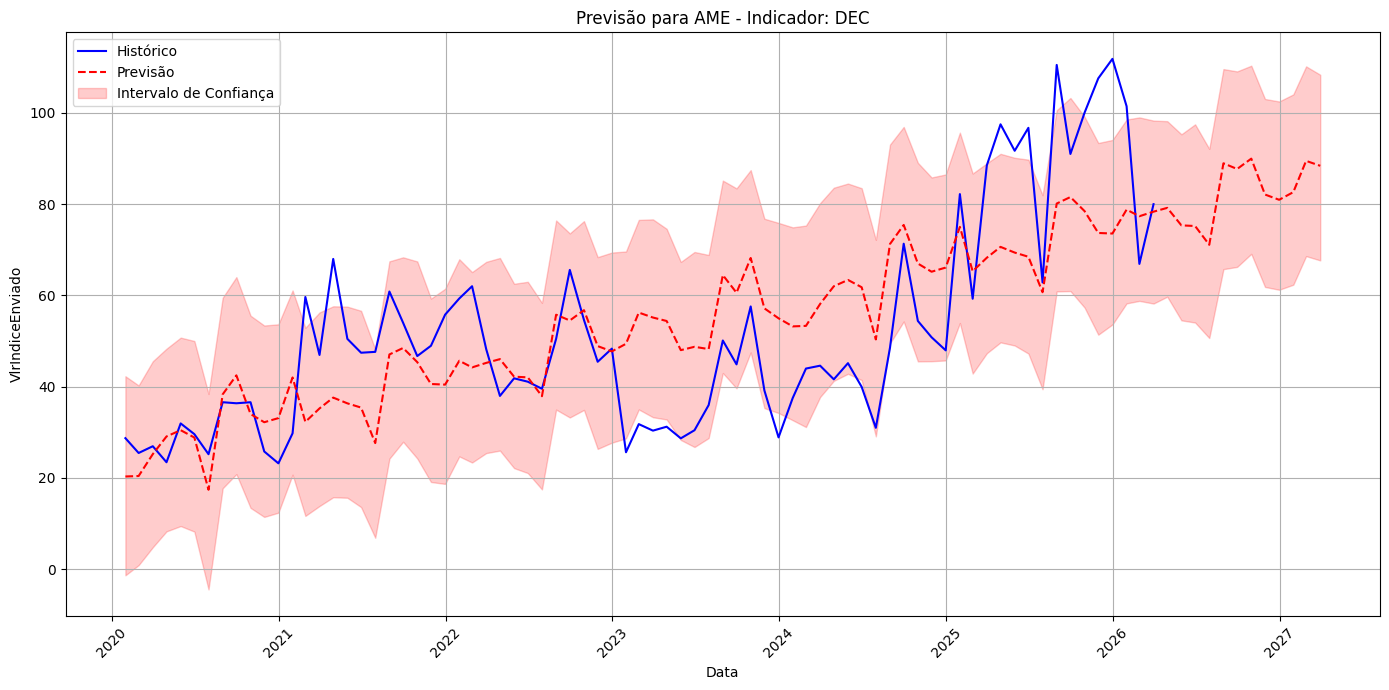

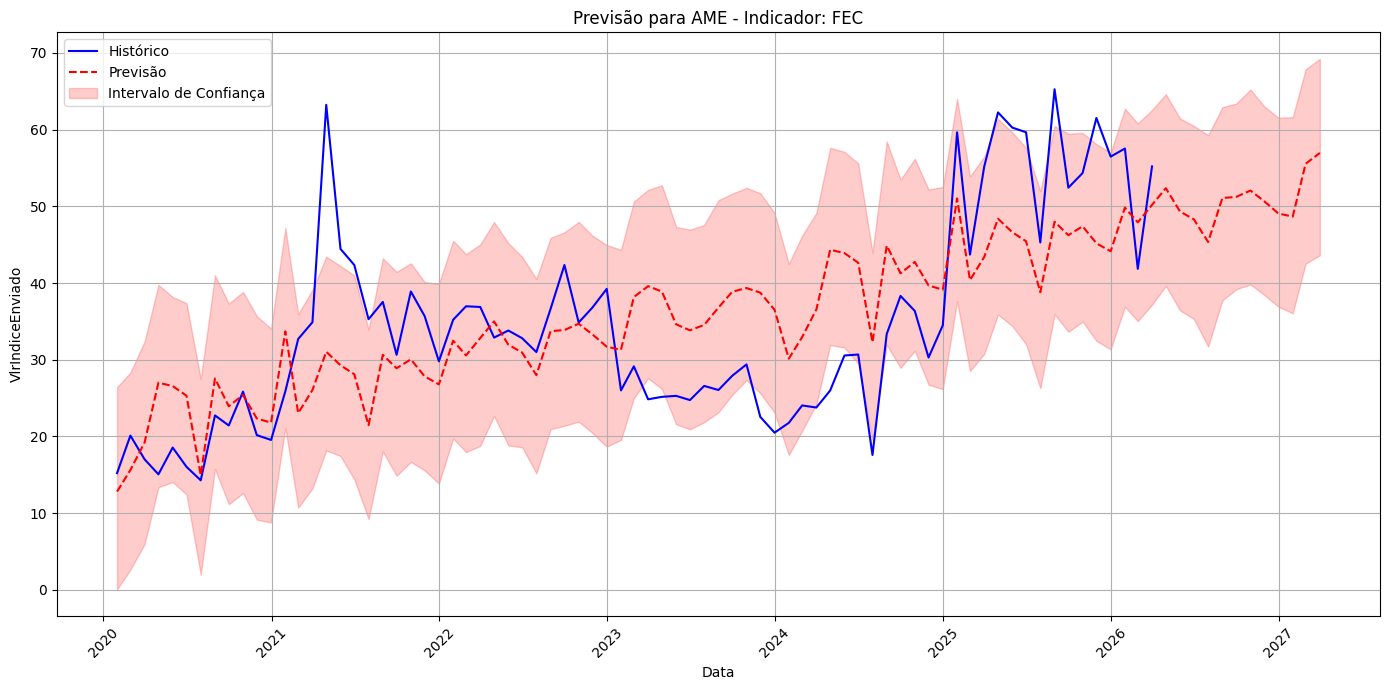

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_forecasts_for_agente(selected_agente):
    print(f"Exibindo previsões para a Distribuidora: {selected_agente}")

    indicators_to_plot = ['DEC', 'FEC']

    for indicador in indicators_to_plot:

        key = (selected_agente + ' ' * (20 - len(selected_agente)), indicador)

        if key in prophet_forecasts:
            forecast_df = prophet_forecasts[key]

            group_df = df_hierarchical_agg[(df_hierarchical_agg['SigAgente'].str.strip() == selected_agente) & (df_hierarchical_agg['SigIndicador'] == indicador)]
            historical_data = group_df[['AnoMes', 'VlrIndiceEnviado']].rename(columns={'AnoMes': 'ds', 'VlrIndiceEnviado': 'y'})

            plt.figure(figsize=(14, 7))
            sns.lineplot(x='ds', y='y', data=historical_data, label='Histórico', color='blue')
            sns.lineplot(x='ds', y='yhat', data=forecast_df, label='Previsão', color='red', linestyle='--')
            plt.fill_between(forecast_df['ds'], forecast_df['yhat_lower'], forecast_df['yhat_upper'], color='red', alpha=0.2, label='Intervalo de Confiança')

            plt.title(f"Previsão para {selected_agente} - Indicador: {indicador}")
            plt.xlabel('Data')
            plt.ylabel('VlrIndiceEnviado')
            plt.legend()
            plt.grid(True)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print(f"  Dados não encontrados para {selected_agente} - Indicador: {indicador}")


plot_forecasts_for_agente("AME")


